---
title: Deriving Secret Sales Volumes with Bayesian Inference
subtitle: Using RxInfer to decouple two signals
author: Kobus Esterhuysen
date: '2024-10-12'
date-modified: last-modified
categories:
  - Retail Industry
  - Bayesian Inference
  - Active Inference
  - RxInfer
  - Julia
image: DerivingSecretSalesVolumes.png
format:
  html:
    toc: true
    toc-depth: 4
    toc-expand: true
    toc-title: TOC
    code-fold: false
---

In [ ]:
#| hide
# BASED ON
  # DerivingSecretSalesVolumes_BLOG^V2.ipynb
  # DerivingSecretSalesVolumes_BLOG^V1.ipynb
  # Kalman filtering and smoothing-2_ANNO^V5.ipynb, Combination 1
  # Kalman filtering and smoothing_ANNO^V4.ipynb
  # Kalman filtering and smoothing_ANNO^V3.ipynb
  # Kalman filtering and smoothing_ANNO^V2.ipynb
  # Kalman filtering and smoothing_ANNO^V1.ipynb
  # GP regression by SSM.ipynb

# DONE
# v1 starts ------------------------------------------------
# migrated to RxInfer 3.0.0
# brought over my changes from RxInfer v2.16.2
# Use \mathbf for structures
# x_tL1 & w_tL1 with nice subscripts
# v2 starts ------------------------------------------------
# \mathcal{P} & \mathcal{Q} --> \mathbf{P} & \mathbf{Q}
# insert f() & g() functions
  # works with generating data; took out again to rather have same in both places
  # does NOT work inside @model (same as https://learnableloop.ai/posts/WeightVsHeight_BLOG.html)
    # seems to take literal symbols in the code to build FFG, so
      # x[t] ~ MvNormalMeanCovariance(f(A= A, xₜ₋₁= xₜ₋₁) does not work
# generate_data() --> sim_point_data
# for 'system identification' section: x --> v
  # the 'x' here is not associated with state but just a name for one of the signals
  # 'v' will go better with the other signal called 'w'
# s (for sum, in 'system identification' section) --> z
  # need s for state (which still need to be changed)
# v3 starts ------------------------------------------------
# change x --> s (for state)
# add tildes to hidden state
# v4 starts ------------------------------------------------
# switch roles of A & B
# change P matrix to R matrix
# clean up missing data section
# standardize symbols to DeVries
# have fp() & fr() in envir, but not in agent
  # maybe in future can remove fp() & fr() from envir too
      # so that they look more similar
      # however, I need to have fp() & fr() implemented somewhere 
# v5 starts ------------------------------------------------
# split into 3 parts
# clean
# v1 starts ------------------------------------------------
# change parameter values to give positive values to use as sales volumes
# update narrative
# v2 starts ------------------------------------------------
# clean for publishing
# v3 starts ------------------------------------------------
# migrate to cursor & github
# change s --> x (for state)
# tildes --> * for true quantities
# switch roles of A & B back again to eng convention, but B --> C
# remove all underscores indicating globals
# add underscores for bold symbols which have spatial structure

# TODO
# clean for publishing

# insert (modified) CRISP-DM structure
# replace code vars with math symbols
  # makes mapping between literature and code better to enhance understanding
  # make expressions more concise due to reduced wordyness
# replace hardcoded parameters with symbols


In [1]:
versioninfo() ## Julia version

Julia Version 1.10.5
Commit 6f3fdf7b362 (2024-08-27 14:19 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 12 × Intel(R) Core(TM) i7-8700B CPU @ 3.20GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)


In [2]:
import Pkg
Pkg.add(Pkg.PackageSpec(;name="RxInfer"))
Pkg.add("Plots")
Pkg.add("StableRNGs")
Pkg.add("LaTeXStrings")
Pkg.add("Distributions")

using RxInfer, Random, Plots, StableRNGs, LaTeXStrings, Distributions

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [3]:
Pkg.status()

Status `~/.julia/environments/v1.10/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [31c24e10] Distributions v0.25.131
  [7073ff75] IJulia v1.34.4
  [b964fa9f] LaTeXStrings v1.4.1
  [91a5bcdd] Plots v1.41.7
  [86711068] RxInfer v5.5.2
  [860ef19b] StableRNGs v1.0.4


# Deriving Secret Sales Volumes

This use case of active inference comes from the retail industry. We use the published sales volume of a company over 250 time intervals. They state that this volume is composed of two components: 

- Product sales
- Rental sales 

For strategic reasons they only publish the combined volume. Their competitor came to us with a request to try and decouple the underlying signals. This will help the competitor to decide on a strategic repositioning in the marketplace.

To test our approach, we will use a simple random walk model to simulate both the product sales volume as well as the rental sales volume. We also add these two signals to simulate the published combined sales volume. Then we will use Bayesian inference inside the `RxInfer` Julia package to attempt to decouple the two sales volume signals - one for product volume and the other for rental volume. During inference we will not have access to the separate product and rental sales signals, but only to their combination. If it works well enough, we will take the real published data and attempt to decouple the two sales volume signals.



## The Generative Process

### Provision function ($f_p$)
The *provision* function, provides another covariate vector. Because this is a *sequential* system, the provision function defines the transition between the previous state and the current state. This special case of the provision function is known as a *transition* function:

$$p^*_{1t} = f_p(x^*_{1,t-1}) = x^*_{1,t-1}$$

$$p^*_{2t} = f_p(x^*_{2,t-1}) = x^*_{2,t-1}$$

When we add *system noise* the next *state* is produced:

$$x^*_{1t} = \mathcal{N}(p^*_{1t}, \lambda^*{x_1})$$

$$x^*_{2t} = \mathcal{N}(p^*_{2t}, \lambda^*_{x_2})$$

The `*`s indicate that the parameters and variables are hidden and not observed.

In [4]:
## provision function, provides another covariate vector
function fₚ(; xˣₜ₋₁)
    return xˣₜ₋₁
end
## fₚ(xˣₜ₋₁=xˣ₁₍ₜ₋₁₎), fₚ(xˣₜ₋₁=xˣ₂₍ₜ₋₁₎) 

fₚ (generic function with 1 method)

### Response function ($f_r$)
The *response* function, provides the response to the covariate vector.
$$r^*_{t} = f_r(x^*_{1t}, x^*_{2t}) = f(x^*_{1t}, x^*_{2t}) = x^*_{1t} + x^*_{2t} $$

After combining with *observation noise* the *observation* is produced:

$$y_{t} = \mathcal{N}(r^*_{t}, \sigma^{*2}_V)$$


The `*`s indicate that the parameters and variables are hidden and not observed.

In [5]:
## response function, provides the response to covariate vector
function fᵣ(; f, xˣ₁ₜ, xˣ₂ₜ)
    return f(xˣ₁ₜ, xˣ₂ₜ)
end
## fᵣ(; f=+, xˣ₁ₜ=7.0, xˣ₂ₜ=8.0)

fᵣ (generic function with 1 method)

Next, we create the `sim_batch_data(...)` function that accepts an argument $f$ which is a function that captures how the two signals are coupled or combined. We will call the `sim_batch_data()` function with the $+$ function because the product sales volume is simply added to the rental sales volume. 

The function will return the real (but hidden) signals $x^*_1$ and  $x^*_2$ (used for comparison later) and their coupled/combined version $y$. We will use $y$ (the published combined sales volume) as our observations during the inference. We also assume that $y$ is corrupted with some observation noise.

In [6]:
## Data comes from either a simulation/lab (sim|lab) OR from the field (fld)
## Data are handled either in batches (batch) OR online as individual points (point)
## Batch data accumulates either
    ## along the depth/examples dimension/axis (into the screen/page), OR
        ## typical for supervised & unsupervised learning
    ## along the time dimension/axis (down the screen page)
        ## typical for sequential decision learning (reinforcement learning & active inference)
# function sim_batch_data(f, T; seed=123, s̃₁₍ₜ₋₁₎, s̃₂₍ₜ₋₁₎, τ̃_s₁, τ̃_s₂, σ̃²ᵥ)
function sim_batch_data(f, T; seed, xˣ₁₍ₜ₋₁₎, xˣ₂₍ₜ₋₁₎, λˣ_x₁, λˣ_x₂, σˣ²ᵥ)
    rng = StableRNG(seed)
    pˣ₁ = Vector{Float64}(undef, T)
    xˣ₁ = Vector{Float64}(undef, T)
    pˣ₂ = Vector{Float64}(undef, T)
    xˣ₂ = Vector{Float64}(undef, T)
    rˣ = Vector{Float64}(undef, T)
    y = Vector{Float64}(undef, T)
    for t in 1:T
        pˣ₁[t] = fₚ(xˣₜ₋₁=xˣ₁₍ₜ₋₁₎)
        xˣ₁[t] = rand(rng, Normal(pˣ₁[t], sqrt(1.0/λˣ_x₁)))
        pˣ₂[t] = fₚ(xˣₜ₋₁=xˣ₂₍ₜ₋₁₎)
        xˣ₂[t] = rand(rng, Normal(pˣ₂[t], sqrt(1.0/λˣ_x₂)))
        rˣ[t] = fᵣ(f=f, xˣ₁ₜ=xˣ₁[t], xˣ₂ₜ=xˣ₂[t])
        y[t] = rand(rng, Normal(rˣ[t], sqrt(σˣ²ᵥ)))
        xˣ₁₍ₜ₋₁₎ = xˣ₁[t]
        xˣ₂₍ₜ₋₁₎ = xˣ₂[t]
    end
    return xˣ₁, xˣ₂, y
end

sim_batch_data (generic function with 1 method)

First, let us create a synthetic dataset:

In [7]:
xˣ₁₍ₜ₋₁₎ = 40.0
xˣ₂₍ₜ₋₁₎ = 20.0

λˣ_x₁ = 1.0
λˣ_x₂ = 1.0

σˣ²ᵥ = 20.0 ##observation noise
seed = 222
T = 250

250

In [10]:
xˣ₁_seq, xˣ₂_seq, y_seq = sim_batch_data(
    +, T; 
    seed=seed,
    xˣ₁₍ₜ₋₁₎=xˣ₁₍ₜ₋₁₎, xˣ₂₍ₜ₋₁₎=xˣ₂₍ₜ₋₁₎, 
    λˣ_x₁=λˣ_x₁, λˣ_x₂=λˣ_x₂, 
    σˣ²ᵥ=σˣ²ᵥ);

In [12]:
xˣ₁_seq

250-element Vector{Float64}:
 38.17351536500037
 38.77424066555762
 38.0649901128261
 37.88494841327824
 38.32316266962699
 37.9709503143836
 37.92445739678425
 39.242134600059345
 39.75171798148435
 39.00489489933928
 39.6526299933459
 39.25477502050384
 39.354198334891024
  ⋮
  5.813780284901366
  5.696807759168373
  6.8102968772838
  5.229725647688231
  6.1355497052670325
  6.004826916013331
  6.285939765621888
  6.169350874135184
  5.982917077260892
  8.04753374496972
  6.996226689895888
  6.879849314673978

In [13]:
xˣ₂_seq

250-element Vector{Float64}:
 20.827514379359563
 21.836968985674375
 23.319198323841803
 23.800911955617885
 23.690922682811433
 22.885366024383806
 22.872966512102174
 21.67113389505316
 22.684780998372805
 19.758996186852205
 20.15050798220582
 20.39850685057507
 20.736518329857994
  ⋮
 33.22411677709458
 32.55498241295711
 31.023058728779805
 31.085429600320868
 32.03089890414834
 31.826225724635243
 30.535300132388816
 30.68245473546646
 30.705134833295908
 30.23491684777188
 30.10640420518613
 30.761763390055563

In [14]:
y_seq

250-element Vector{Float64}:
 51.055772694424824
 59.95111148432222
 55.05654278445259
 62.45589589491548
 57.256104599566946
 66.24912791331924
 63.3860861039736
 66.46907679463577
 65.17701380960303
 59.18125677519563
 62.37801819808789
 53.73889929962076
 53.50706496178381
  ⋮
 31.000477537297083
 37.315899676873684
 32.535648724925956
 34.39902507080608
 38.54427167243298
 40.46984799252074
 43.82615990686573
 38.467290944324475
 35.19221692251506
 39.40013064479152
 40.61920355195525
 39.98054648387227

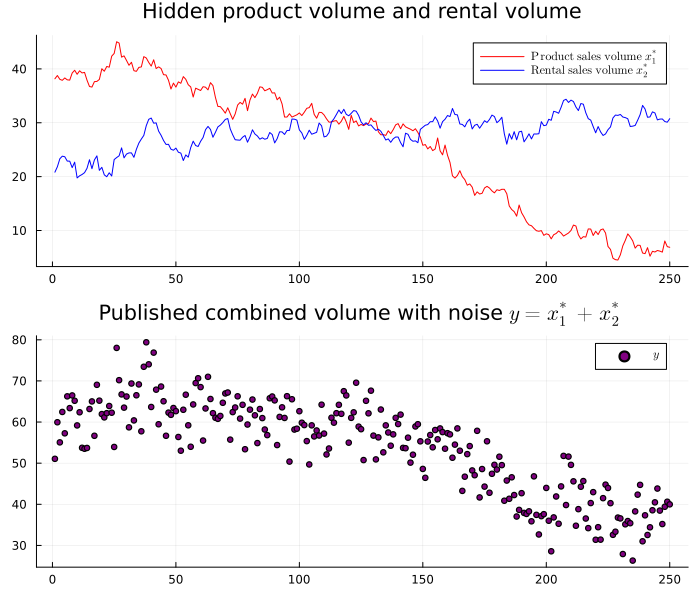

In [16]:
p1 = plot(title="Hidden product volume and rental volume")
p1 = plot!(p1, xˣ₁_seq, label=L"\mathrm{Product\ sales\ volume\ } x^*_1", c="red")
p1 = plot!(p1, xˣ₂_seq, label=L"\mathrm{Rental\ sales\ volume\ } x^*_2", c="blue")

p2 = plot(title="Published combined volume with noise " * L"y = x^*_1 + x^*_2")
p2 = scatter!(p2, y_seq, ms=3, color=:purple, label=L"y")
plot(p1, p2, size=(700, 600), layout=(2,1))

## The Generative Model

Next, we create a probabilistic model to perform inference. We use the `RxInfer` package:

In [17]:
@model function decouple_model(f, y_seq, m₁₀, λ₁₀, a₁, b₁, m₂₀, λ₂₀, a₂, b₂, a_y, b_y)
    x₁₀ ~ Normal(mean=m₁₀, precision=λ₁₀)
    λ_x₁ ~ Gamma(shape=a₁, rate=b₁)
    x₂₀ ~ Normal(mean=m₂₀, precision=λ₂₀)
    λ_x₂ ~ Gamma(shape=a₂, rate=b₂)
    λ_y ~ Gamma(shape=a_y, rate=b_y)
    x₁₍ₜ₋₁₎ = x₁₀
    x₂₍ₜ₋₁₎ = x₂₀
    local x₁
    local x₂
    local z
    for t in 1:length(y_seq)
        x₁_seq[t] ~ Normal(mean=x₁₍ₜ₋₁₎, precision=λ_x₁)
        x₂_seq[t] ~ Normal(mean=x₂₍ₜ₋₁₎, precision=λ_x₂)
        z_seq[t] ~ f(x₁_seq[t], x₂_seq[t])
        y_seq[t] ~ Normal(mean=z_seq[t], precision=λ_y)
        x₁₍ₜ₋₁₎ = x₁_seq[t]
        x₂₍ₜ₋₁₎ = x₂_seq[t]
    end
end

`RxInfer` runs Bayesian inference as a variational optimisation procedure between the real solution and its variational proxy `q`. In our model specification we assumed noise components to be unknown so we need to enforce a structured mean-field assumption for the variational family of distributions `q`. This inevitably reduces the accuracy of the result, but makes the task easier and allows for fast and analytical message passing-based variational inference:

In [18]:
constraints = @constraints begin
    q(x₁₀, x₂₀, x₁_seq, x₂_seq, λ_x₁, λ_x₂, λ_y, z_seq) = q(x₁_seq, x₁₀, x₂_seq, x₂₀, z_seq)q(λ_x₂)q(λ_x₁)q(λ_y)
end

Constraints: 
  q(x₁₀, x₂₀, x₁_seq, x₂_seq, λ_x₁, λ_x₂, λ_y, z_seq) = q(x₁_seq, x₁₀, x₂_seq, x₂₀, z_seq)q(λ_x₂)q(λ_x₁)q(λ_y)


Next, we need to assign priors, initialize the messages needed, and the marginals, and then call the `infer` function:

In [21]:
m₁₀, λ₁₀ = 40.0, 0.10
m₂₀, λ₂₀ = 20.0, 0.10

## strong priors for the random walk noise components
a₁, b₁ = 0.02, 0.1var(xˣ₁_seq)
a₂, b₂ = 0.02, 0.1var(xˣ₂_seq)

## vague prior for the observation noise
a_y, b_y = 1.0, 1.0

## strong priors for messages
x₁_init = map(r -> NormalMeanPrecision(r, λ₁₀), reverse(range(-50, -20, length=T)))
x₂_init = map(r -> NormalMeanPrecision(r, λ₂₀), range(20, 50, length=T))

init = @initialization begin
    μ(x₁_seq) = x₁_init
    μ(x₂_seq) = x₂_init
    q(λ_x₁) = GammaShapeRate(a₁, b₁)
    q(λ_x₂) = GammaShapeRate(a₂, b₂)
    q(λ_y) = GammaShapeRate(a_y, b_y)
end

result = infer(
    model = decouple_model(
        f=+, 
        m₁₀=m₁₀, λ₁₀=λ₁₀, a₁=a₁, b₁=b₁, 
        m₂₀=m₂₀, λ₂₀=λ₂₀, a₂=a₂, b₂=b₂, 
        a_y=a_y, b_y=b_y),
    data  = (y_seq = y_seq,), 
    options = (limit_stack_depth = 500, ), 
    constraints = constraints, 
    initialization = init,
    iterations = 50
)

Inference results:
  Posteriors       | available for (x₂₀, x₁₀, x₂_seq, λ_x₂, x₁_seq, λ_y, λ_x₁, z_seq)


In [22]:
result.posteriors

Dict{Symbol, Vector} with 8 entries:
  :x₂₀    => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{F…
  :x₁₀    => NormalWeightedMeanPrecision{Float64}[NormalWeightedMeanPrecision{F…
  :x₂_seq => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPr…
  :λ_x₂   => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.02, b=1051.8…
  :x₁_seq => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPr…
  :λ_y    => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=126.0, b=127.096…
  :λ_x₁   => GammaShapeRate{Float64}[GammaShapeRate{Float64}(a=125.02, b=1656.8…
  :z_seq  => Vector{NormalWeightedMeanPrecision{Float64}}[[NormalWeightedMeanPr…

The inference results:

In [23]:
λ_x₁_marginals = result.posteriors[:λ_x₁]
λ_x₂_marginals = result.posteriors[:λ_x₂]
λ_y_marginals = result.posteriors[:λ_y]

z_marginals = result.posteriors[:z_seq]
x₁_marginals = result.posteriors[:x₁_seq]
x₂_marginals = result.posteriors[:x₂_seq];

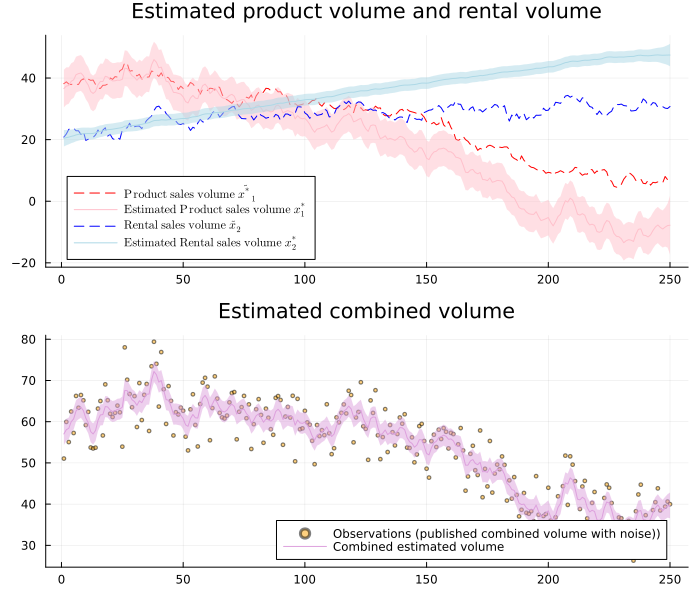

In [26]:
p1 = plot(legend=:bottomleft, title="Estimated product volume and rental volume")
p1 = plot!(p1, xˣ₁_seq, label=L"\mathrm{Product\ sales\ volume\ } \tilde{x^*}_1", c="red", linestyle=:dash)
p1 = plot!(p1, mean.(x₁_marginals[end]), ribbon=var.(x₁_marginals[end]), label=L"\mathrm{Estimated\ Product\ sales\ volume\ } x^*_1", color=:pink)

p1 = plot!(p1, xˣ₂_seq, label=L"\mathrm{Rental\ sales\ volume\ } \tilde{x}_2", color=:blue, linestyle=:dash)
p1 = plot!(p1, mean.(x₂_marginals[end]), ribbon=var.(x₂_marginals[end]), label=L"\mathrm{Estimated\ Rental\ sales\ volume\ } x^*_2", color=:lightblue)

p2 = plot(legend=:bottomright, title="Estimated combined volume")
p2 = scatter!(p2, y_seq, label="Observations (published combined volume with noise))", ms=2, alpha=0.5, color=:orange)
p2 = plot!(p2, mean.(z_marginals[end]), ribbon=std.(z_marginals[end]), label="Combined estimated volume", color="plum")

plot(p1, p2, size=(700, 600), layout=(2,1))

The inferred hidden signals track the their hidden counterparts initially, but then progressively deviates increasingly. We can conclude that the product volume declines consistently, but that the rental volume keeps on increasing, or at least does not show a declining trend. This kind of information could be valuable for the competitor that approached us. Based on the simulation results, they may just decide to position themselves to compete more aggresively in the product space (due to reduced competition), rather than the rental space.